In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")


In [2]:

NORMAL_FILES = [
    "data/cleaned_combined.csv",
]

CPU_COL  = "Processor_% Processor Time"
MEM_COL  = "Memory_Pages/sec"
IO_COL   = "Process_IO Data Bytes/sec"
IDLE_COL = "Processor_% Idle Time"

LABEL_COLS = {CPU_COL, MEM_COL, IO_COL, IDLE_COL}

LEAKY_COLS = {
    "Processor_% User Time",
    "Processor_% Privileged Time",
    "Processor_% DPC Time",
    "Processor_% Interrupt Time",
    "Processor_% C1 Time",
    "Processor_% C2 Time",
    "Processor_% C3 Time",
}

FEATURE_COLS = [
    "Processor_Interrupts/sec",
    "Processor_DPCs Queued/sec",
    "Processor_DPC Rate",
    "Process_IO Read Bytes/sec",
    "Process_IO Write Bytes/sec",
    "Process_IO Data Operations/sec",
    "Process_IO Read Operations/sec",
    "Process_Working Set",
    "Process_Working Set - Private",
    "Process_Page Faults/sec",
    "Process_Thread Count",
    "Process_Handle Count",
    "Memory_Page Faults/sec",
    "Memory_Demand Zero Faults/sec",
    "Memory_Available MBytes",
    "Memory_% Committed Bytes In Use",
    "Memory_Cache Faults/sec",
    "Memory_Transition Faults/sec",
    "Memory_Pages Input/sec",
    "Memory_Pages Output/sec",
    "Memory_Pages/sec",
]

In [3]:
TEST_SIZE        = 0.25
RANDOM_SEED      = 42
N_ESTIMATORS     = 200
MAX_DEPTH        = None
MIN_SAMPLES_LEAF = 20
N_JOBS           = -1
CV_FOLDS         = 5
TOP_N_FEATURES   = 15

In [4]:
def strip_host(col: str) -> str:
    return re.sub(r"^\\\\[^\\]+\\", "", col).strip()


def load_pdh_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [strip_host(c) if i > 0 else "ts" for i, c in enumerate(df.columns)]
    df = df.drop(columns=["ts"], errors="ignore")
    df = df.replace(" ", np.nan)
    return pd.to_numeric(df.stack(), errors="coerce").unstack()


def load_data() -> tuple:
    data = pd.read_csv("data/cleaned_combined.csv", low_memory=False)
    common = [
        c for c in data.columns
        if c not in ["timestamp", "os", "label", "source_file"]
]
    data = data.dropna(thresh=int(0.2 * len(common)))
    return data, common

In [5]:

def assign_load_state(df: pd.DataFrame) -> pd.Series:
    cpu = df[CPU_COL].fillna(0)
    mem = df[MEM_COL].fillna(0)
    io  = df[IO_COL].fillna(0)

    state = pd.Series("Active", index=df.index)
    state[cpu >= 30] = "Stressed"
    state[(mem > 200) & (io > 1e6)] = "Stressed"
    state[(cpu < 5) & (io < 5e4)] = "Idle"
    return state


def plot_confusion_matrix(y_test: np.ndarray, y_pred: np.ndarray, classes: list):
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix — Random Forest Load State")
    plt.tight_layout()
    plt.show()


In [6]:
def plot_feature_importance(model: RandomForestClassifier, feat_cols: list):
    fi = pd.Series(model.feature_importances_,
                   index=[c.split("\\")[-1] for c in feat_cols])
    fi = fi.sort_values(ascending=True).tail(TOP_N_FEATURES)

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(fi.index, fi.values, color="#7F77DD", edgecolor="white", linewidth=0.5)

    for bar, val in zip(bars, fi.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8)

    ax.set_xlabel("Mean Decrease in Gini Impurity")
    ax.set_title(f"Top {TOP_N_FEATURES} Feature Importances — Random Forest")
    ax.set_xlim(0, fi.values.max() * 1.18)
    plt.tight_layout()
    plt.show()

In [7]:
def plot_roc_curves(y_test: np.ndarray, y_prob: np.ndarray, classes: list):
    y_bin = label_binarize(y_test, classes=classes)
    colors = ["#378ADD", "#1D9E75", "#E24B4A"]

    fig, ax = plt.subplots(figsize=(7, 6))
    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{cls} (AUC = {roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("One-vs-Rest ROC Curves — Random Forest Load State")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

Loading cleaned dataset ...
Load state distribution:
load_state
Active      16564
Stressed     8438
Idle         4144

Samples: 29146   Features: 21

Cross-validation accuracy (5-fold): 0.9286 +/- 0.0047

RANDOM FOREST — EVALUATION
              precision    recall  f1-score   support

      Active       0.93      0.95      0.94      4141
        Idle       0.98      0.99      0.98      1036
    Stressed       0.91      0.87      0.89      2110

    accuracy                           0.93      7287
   macro avg       0.94      0.94      0.94      7287
weighted avg       0.93      0.93      0.93      7287

Accuracy : 0.9341

Top 15 features by importance:
                        feature  importance
       Processor_Interrupts/sec    0.171406
         Memory_Page Faults/sec    0.125133
  Memory_Demand Zero Faults/sec    0.117335
  Process_Working Set - Private    0.110187
      Processor_DPCs Queued/sec    0.068130
        Process_Page Faults/sec    0.067997
            Process_Working S

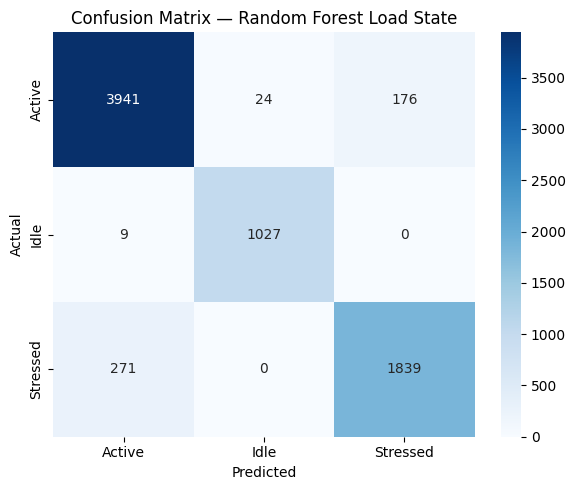

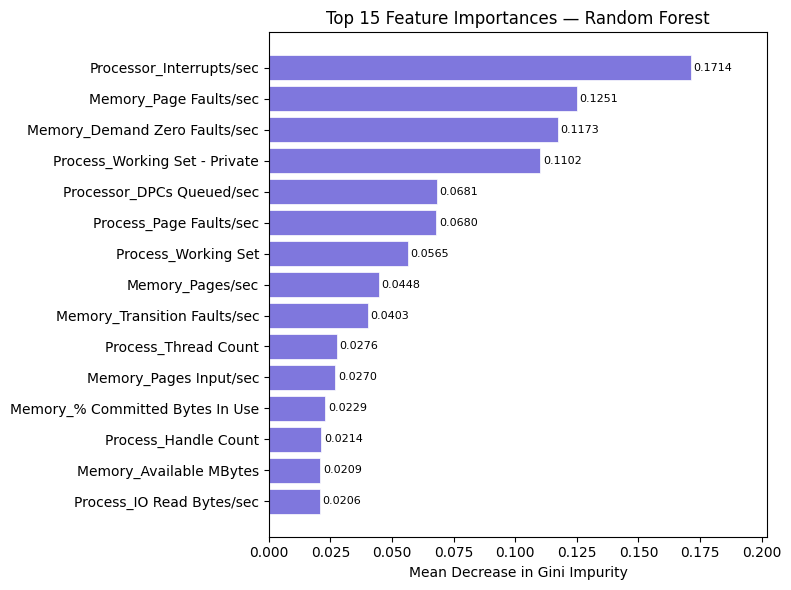

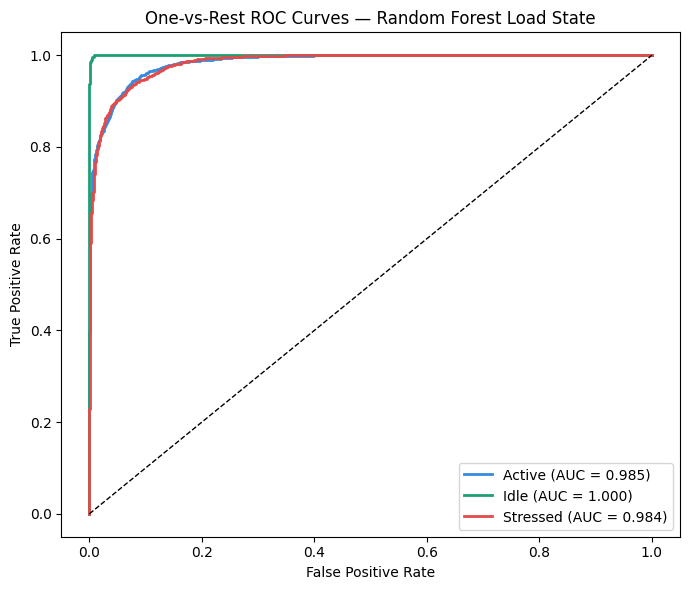

In [8]:
print("Loading cleaned dataset ...")
data, common = load_data()

data["load_state"] = assign_load_state(data)
print("Load state distribution:")
print(data["load_state"].value_counts().to_string())

feat_cols = [c for c in FEATURE_COLS if c in common]
if not feat_cols:
    feat_cols = [c for c in common if c not in LABEL_COLS]
print(f"\nSamples: {len(data)}   Features: {len(feat_cols)}")

X = data[feat_cols].fillna(0)
y = data["load_state"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)
model.fit(X_tr, y_tr)

cv_scores = cross_val_score(model, X_tr, y_tr, cv=CV_FOLDS, scoring="accuracy", n_jobs=N_JOBS)
print(f"\nCross-validation accuracy ({CV_FOLDS}-fold): "
        f"{cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

y_pred = model.predict(X_te)
y_prob = model.predict_proba(X_te)

print("\n" + "=" * 50)
print("RANDOM FOREST — EVALUATION")
print("=" * 50)
print(classification_report(y_te, y_pred, target_names=model.classes_))
print(f"Accuracy : {accuracy_score(y_te, y_pred):.4f}")
print("=" * 50)

fi_df = pd.DataFrame({
    "feature": feat_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)
print(f"\nTop {TOP_N_FEATURES} features by importance:")
print(fi_df.head(TOP_N_FEATURES).to_string(index=False))

classes_ordered = list(model.classes_)
plot_confusion_matrix(y_te.to_numpy(), y_pred, classes_ordered)
plot_feature_importance(model, feat_cols)
plot_roc_curves(y_te.to_numpy(), y_prob, classes_ordered)